<a href="https://colab.research.google.com/github/ayeung009/APS360-Project/blob/main/Data_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# APS360 Project: A Deep Learning Assistant for Digital Circuit Design

##Data Loading & Processing

This section involves:
1. Downloading the Roboflow Logic Gates dataset
2. Inspecting the dataset (currently it has gate bounding boxes, but **not** full Boolean expressions)
3. A manual labelling helper to attach a Boolean expression to each circuit image
4. Combining Roboflow data with self-generated (logic.ly) data
5. Tokenizing Boolean expressions into sequences
6. A PyTorch `Dataset` / `DataLoader` pipeline with train/val/test splits


### 1.1 Setup

If you're in Colab, mount your Drive so downloaded data and labels persist across sessions.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!pip install roboflow torch torchvision matplotlib pandas scikit-learn --quiet


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 97.9 MB/s eta 0:00:00


In [3]:
import os
import re
import json
import random
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torchvision.transforms as T

SEED = 360
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Root directory for all project data — keep this consistent across notebook sections
DATA_ROOT = Path("./data")
DATA_ROOT.mkdir(exist_ok=True)


### 1.2 Download the Roboflow dataset

Get a free API key from https://roboflow.com (Settings → API Keys) and paste it below.
This downloads the "Logic Gates Detection" dataset [2] in COCO format, which gives you
images + bounding boxes per logic gate (AND, OR, NOT, XOR, etc.) — useful context, but
you still need to derive the *overall* Boolean expression per image yourself (Section 1.4).

In [4]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="jnIBN31pWGvXkDE3MePu")
project = rf.workspace("personal-tatwd").project("logic-gates-detection")
version = project.version(12)
dataset = version.download("coco")
#this code from the website

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Logic-Gates-Detection-12 in coco:: 100%|██████████| 305/305 [00:00<00:00, 9281.72it/s]


### 1.3 Inspect the raw dataset

COCO format gives you one `_annotations.coco.json` per split (train/valid/test), each
containing `images`, `annotations` (bounding boxes + category ids), and `categories`
(the gate class names). Let's look at one example.

In [5]:
roboflow_dir = DATA_ROOT / "/content/Logic-Gates-Detection-12" #local data root on google drive.

# COCO splits typically live in train/, valid/, test/ subfolders
split_dirs = [d for d in roboflow_dir.iterdir() if d.is_dir()]
print("Splits found:", [d.name for d in split_dirs])

with open(split_dirs[0] / "_annotations.coco.json") as f:
    coco = json.load(f)

print("Num images:", len(coco["images"]))
print("Categories:", [c["name"] for c in coco["categories"]])

Splits found: ['test', 'train', 'valid']
Num images: 30
Categories: ['logic-gates-circuits', 'AND', 'NAND', 'NOR', 'NOT', 'OR', 'XNOR', 'XOR']


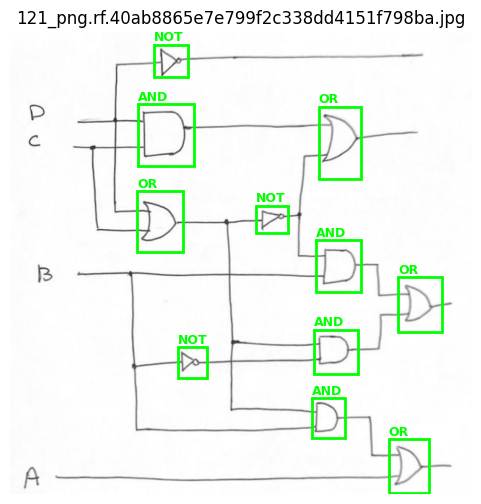

In [6]:
def show_coco_sample(coco_json_path, images_dir, image_index=0):
    with open(coco_json_path) as f:
        coco = json.load(f)

    cat_lookup = {c["id"]: c["name"] for c in coco["categories"]}
    img_info = coco["images"][image_index]
    img_path = Path(images_dir) / img_info["file_name"]
    img = Image.open(img_path).convert("RGB")

    anns = [a for a in coco["annotations"] if a["image_id"] == img_info["id"]]

    fig, ax = plt.subplots(1, figsize=(6, 6))
    ax.imshow(img)
    for a in anns:
        x, y, w, h = a["bbox"]
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
        ax.text(x, y - 5, cat_lookup[a["category_id"]], color="lime", fontsize=9, weight="bold")
    ax.set_title(img_info["file_name"])
    ax.axis("off")
    plt.show()

show_coco_sample(split_dirs[0] / "_annotations.coco.json", split_dirs[0], image_index=0)


### 1.4 Cleaning & Manually Labelling Roboflow dataset: attaching Boolean expressions

Not every Roboflow image is usable — some don't match the clean, unambiguous style
of the self-generated set. This step lets you review each image and either:
- **Accept & label** it (type its Boolean expression), or
- **Reject** it, choosing one of three reasons:
  1. **Bad image quality** — blurry, messy, hard to read
  2. **Missing labels** — inputs aren't clearly labeled (A, B, C, ...)
  3. **Not 1 output** — circuit has more than one output

Every decision is saved to `roboflow_review.csv` so re-running this cell later never
asks you to re-review an image you've already decided on. A live counter shows
accepted / rejected-by-reason as you go.

**Expression format — must match the self-generated dataset's tokenizer exactly**
(the tokenizer in the Training Section does an exact, case-sensitive lookup, no
uppercasing):
- Variables: uppercase, e.g. `A`, `B`, `C`
- Operators: **lowercase**, e.g. `and`, `or`, `not`, `xor`, `nand`, `nor`, `xnor`
- Always put a space **between tokens** (e.g. `D xnor A`, not `DxnorA`) — the
  tokenizer splits on whitespace and won't separate them otherwise
- No space needed directly after `(` or before `)` — matching the self-generated
  style, e.g. `(D xnor A)` not `( D xnor A )`

Example: `(D xnor A) nor B`

In [26]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Tracks both accepted (labeled) and rejected (with a specific reason) images, so
# a re-run of this cell never re-asks about an image already decided on.
REVIEW_CSV = DATA_ROOT / "roboflow_review.csv"
REPO_ROOT = Path.cwd()  # assumes you're running this notebook from the repo root

REJECT_REASONS = {
    "bad_quality": "Bad Quality",
    "missing_labels": "Missing Labels",
    "not_single_output": "Not 1 Output",
}

def _to_relative(img_path):
    return os.path.relpath(Path(img_path).resolve(), REPO_ROOT)

def _load_review():
    if REVIEW_CSV.exists():
        return pd.read_csv(REVIEW_CSV)
    return pd.DataFrame(columns=["image_path", "status", "expression", "reject_reason"])

class ReviewLabeler:
    """status is 'labeled' (good quality, expression given) or 'rejected'.
    reject_reason is one of REJECT_REASONS' keys when status == 'rejected', else blank."""

    def __init__(self, image_paths, source="roboflow"):
        self.source = source
        self.review_df = _load_review()
        already_done = set(self.review_df["image_path"])
        self.queue = [p for p in image_paths if _to_relative(p) not in already_done]
        self.index = 0

        self.counter_label = widgets.HTML()
        self.text = widgets.Text(placeholder="e.g. (D xnor A) nor B", description="Expr:")
        self.save_btn = widgets.Button(description="Accept & Label", button_style="success")

        self.reject_buttons = {
            key: widgets.Button(description=f"Reject: {label}", button_style="danger")
            for key, label in REJECT_REASONS.items()
        }
        self.stop_btn = widgets.Button(description="Stop", button_style="warning")
        self.output = widgets.Output()

        self.text.on_submit(lambda w: self._accept())
        self.save_btn.on_click(lambda b: self._accept())
        for key, btn in self.reject_buttons.items():
            btn.on_click(lambda b, k=key: self._reject(k))
        self.stop_btn.on_click(lambda b: self._stop())

        display(widgets.VBox([
            self.counter_label,
            self.output,
            self.text,
            widgets.HBox([self.save_btn, *self.reject_buttons.values(), self.stop_btn]),
        ]))
        self._render()

    def _counts(self):
        n_labeled = int((self.review_df["status"] == "labeled").sum())
        reason_counts = {
            key: int(((self.review_df["status"] == "rejected") &
                      (self.review_df["reject_reason"] == key)).sum())
            for key in REJECT_REASONS
        }
        n_remaining = len(self.queue) - self.index
        return n_labeled, reason_counts, n_remaining

    def _update_counter(self):
        n_labeled, reason_counts, n_remaining = self._counts()
        n_rejected_total = sum(reason_counts.values())
        total_reviewed = n_labeled + n_rejected_total
        reason_str = " &nbsp;|&nbsp; ".join(
            f"<b>{REJECT_REASONS[k]}:</b> {v}" for k, v in reason_counts.items()
        )
        self.counter_label.value = (
            f"<b>Accepted:</b> {n_labeled} &nbsp;|&nbsp; "
            f"<b>Rejected total:</b> {n_rejected_total} &nbsp;|&nbsp; "
            f"{reason_str} &nbsp;|&nbsp; "
            f"<b>Reviewed:</b> {total_reviewed} &nbsp;|&nbsp; "
            f"<b>Remaining:</b> {n_remaining}"
        )

    def _render(self):
        self._update_counter()
        with self.output:
            clear_output(wait=True)
            if self.index >= len(self.queue):
                print("All done reviewing this batch!")
                return
            img_path = self.queue[self.index]
            img = Image.open(img_path).convert("RGB")
            plt.figure(figsize=(5, 5))
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"{Path(img_path).name}  ({self.index + 1}/{len(self.queue)})")
            plt.show()
        self.text.value = ""

    def _log(self, status, expression="", reject_reason=""):
        rel_path = _to_relative(self.queue[self.index])
        self.review_df = pd.concat([
            self.review_df,
            pd.DataFrame([{
                "image_path": rel_path,
                "status": status,
                "expression": expression,
                "reject_reason": reject_reason,
            }])
        ], ignore_index=True)
        self.review_df.to_csv(REVIEW_CSV, index=False)  # save after every decision

    def _accept(self):
        if self.index >= len(self.queue):
            return
        expr = self.text.value.strip()
        if not expr:
            return  # require an expression to accept; use a Reject button for bad images
        self._log("labeled", expression=expr)
        self._advance()

    def _reject(self, reason_key):
        if self.index >= len(self.queue):
            return
        self._log("rejected", reject_reason=reason_key)
        self._advance()

    def _advance(self):
        self.index += 1
        self._render()

    def _stop(self):
        with self.output:
            clear_output(wait=True)
            print("Stopped. Resume anytime by rerunning this cell.")
        self._update_counter()
        self.index = len(self.queue)


In [27]:
import os

roboflow_dir = DATA_ROOT / "/content/Logic-Gates-Detection-12"
train_dir = roboflow_dir / "train"

print(os.listdir(train_dir)[:10])  # confirm actual filenames/extension (.jpg vs .png)

['Screenshot-2023-12-04-at-21-15-39_png.rf.82d660e0971f8ddbe182f72d64fb94ca.jpg', '138_png.rf.21051f60f0fb0e448e7a128e9865e979.jpg', '136_png.rf.d78e848ac988fae6e49ee9dc922af42f.jpg', 'Screenshot-2023-08-16-at-12-43-41-PM-12-54-24-PM_png.rf.cba4c134df7f3cd69bc4f99937e68228.jpg', '113_png.rf.e4f73b53a21280709bfb6a69fd98b761.jpg', 'Screenshot-2023-08-16-at-12-45-01-PM-12-54-24-PM_png.rf.a21be03d33e9523a059b023d9446e9af.jpg', '14_png.rf.d9f91753649238aceabcbe29b0609609.jpg', '82_png.rf.a7001159afdc69246ef756b99f0ebb9d.jpg', '11_png.rf.bd04392f4f955827480428347e6b2f07.jpg', '94_png.rf.4273579926601b733c3b27a218c7a644.jpg']


Found 209 images


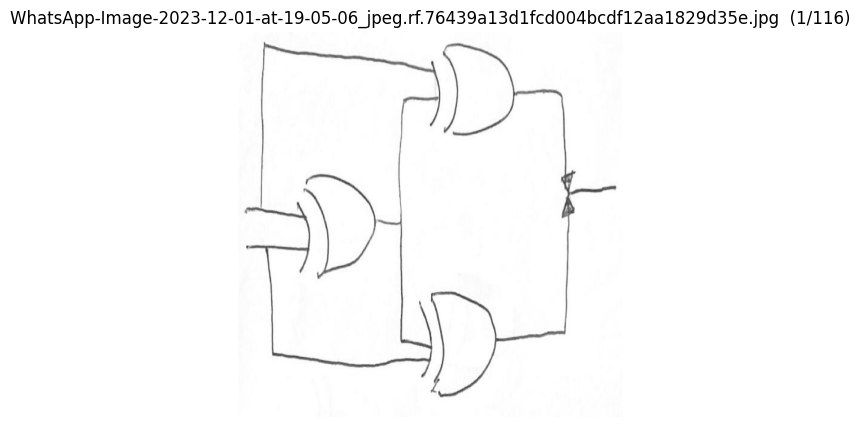

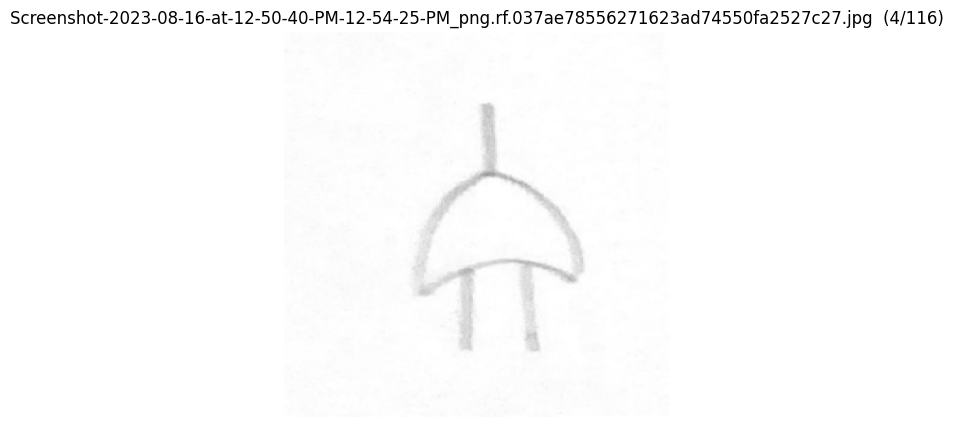

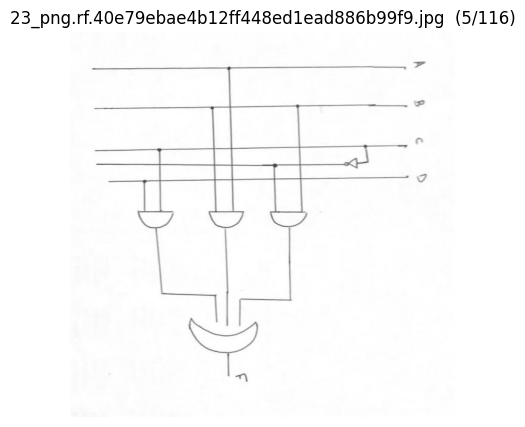

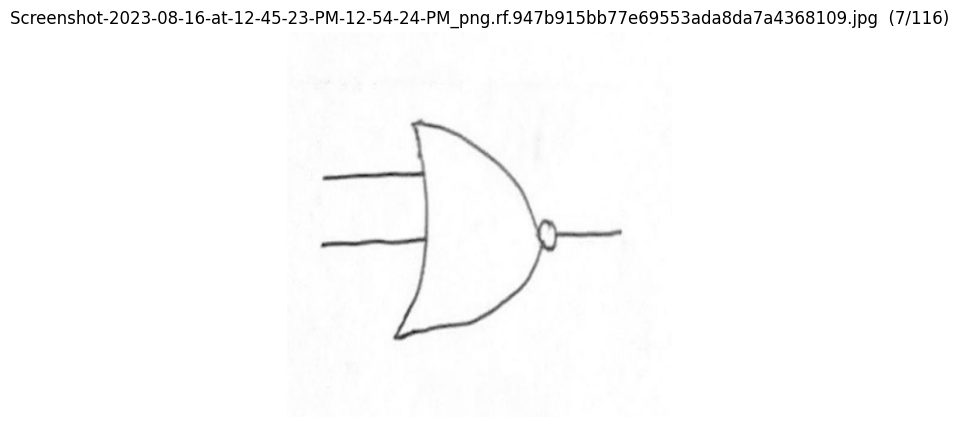

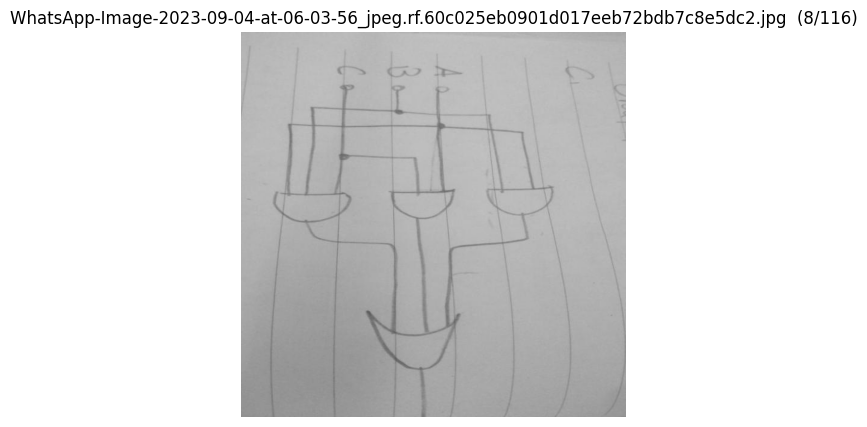

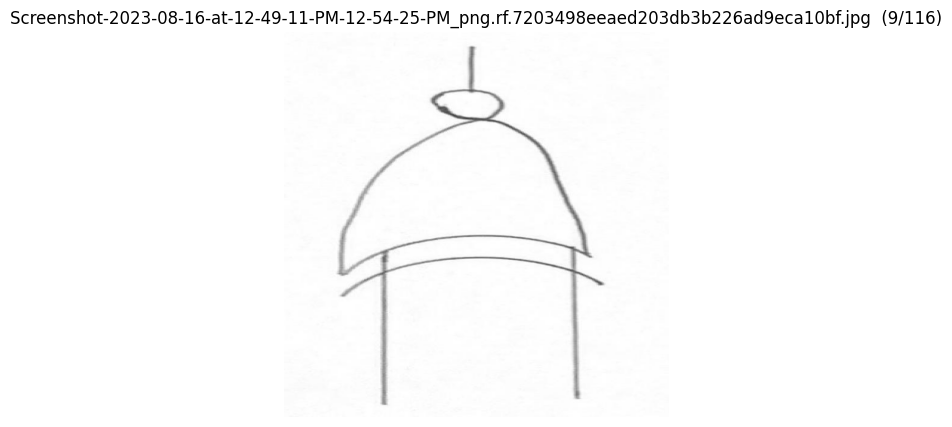

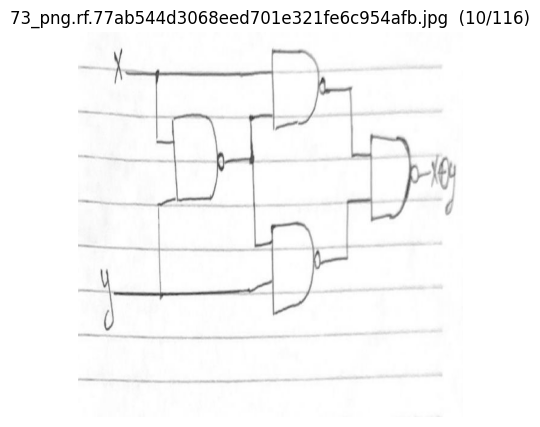

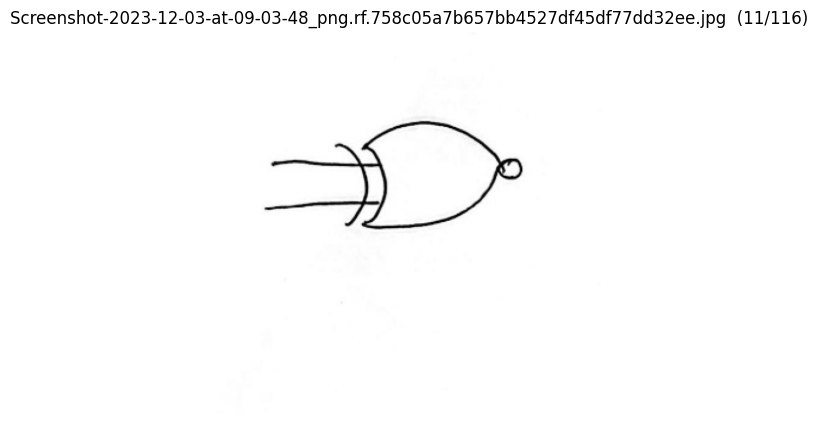

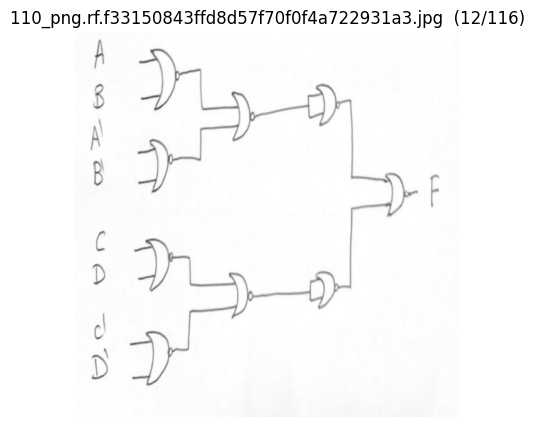

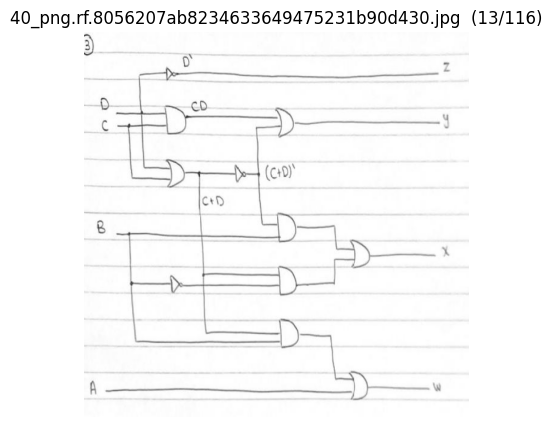

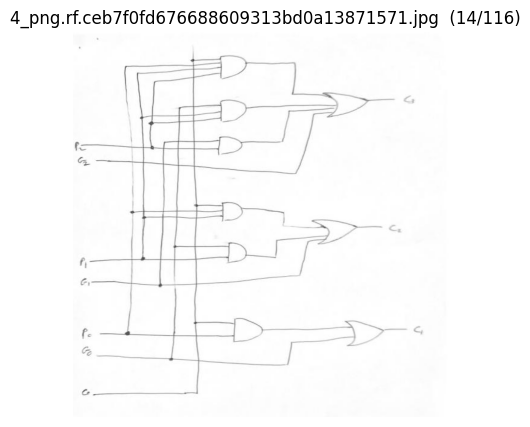

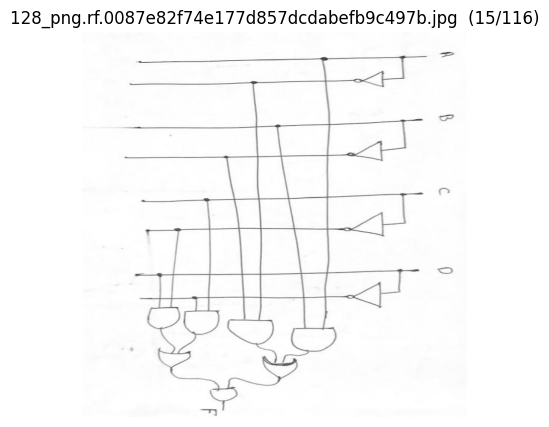

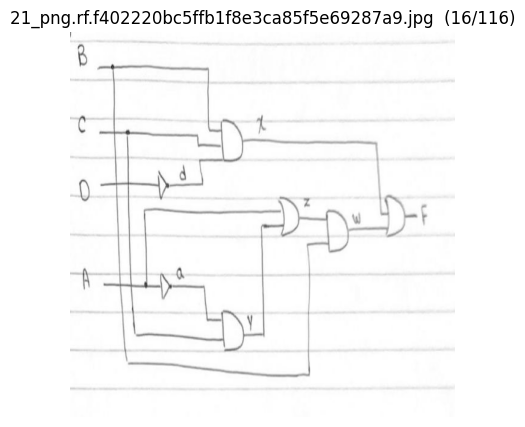

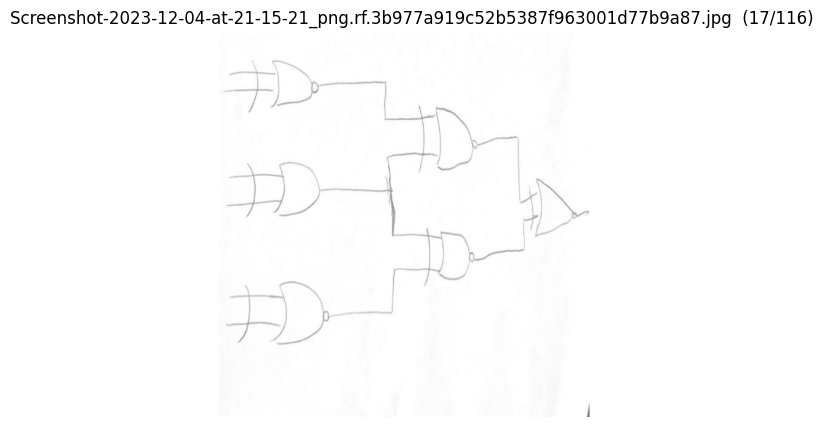

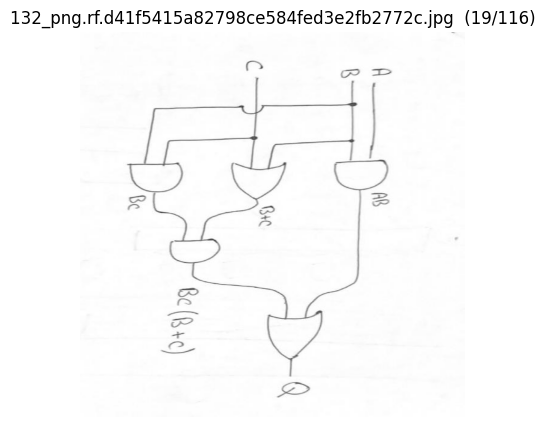

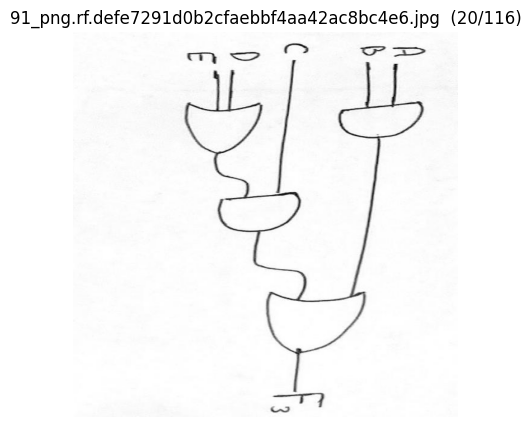

In [36]:
all_roboflow_images = list(train_dir.glob("*.jpg"))  # match the extension you confirmed earlier
print(f"Found {len(all_roboflow_images)} images")

reviewer = ReviewLabeler(all_roboflow_images, source="roboflow")

In [24]:
review_df = _load_review()
print(f"Review log: {REVIEW_CSV.resolve()}")
if len(review_df):
    n_labeled = (review_df["status"] == "labeled").sum()
    n_rejected = (review_df["status"] == "rejected").sum()
    n_total = len(review_df)
    print(f"Accepted : {n_labeled}")
    print(f"Rejected total : {n_rejected}")
    if n_rejected:
        print("  Breakdown by reason:")
        for key, label in REJECT_REASONS.items():
            count = ((review_df["status"] == "rejected") & (review_df["reject_reason"] == key)).sum()
            print(f"    {label}: {count}")
    print(f"Total reviewed so far : {n_total}")
    print(f"Acceptance rate : {n_labeled / n_total:.1%}")
else:
    print("No reviews yet.")

Review log: /content/data/roboflow_review.csv
No reviews yet.


# Self Generated Data Section

Data generated in this section will produce custom digital circuit images and a csv file that has the associated labels.

The following automation tool for image generation was used: https://schemdraw.readthedocs.io/en/stable/elements/logic.html

In [12]:
!pip install schemdraw

In [13]:
!pip install --upgrade schemdraw

**Dataset Generation through Randomization**

While this script generates the data, it also updates statistics and counters to track information about the clean data. For instance, it tracks the number of images that have only 2 circuit inputs. More info is stored in the csv file of statistics that this script generates.

In [19]:
import os
import random
import pandas as pd
from tqdm import tqdm
from schemdraw.parsing import logicparse
from collections import Counter

NUM_SAMPLES = 1000
OUTPUT_DIR = "logic_dataset"

records = []
seen = set()

# Dataset Statistics
input_counter = Counter()
gate_counter = Counter()
gate_count_counter = Counter()
not_counter = Counter()
expression_length_counter = Counter()
variable_counter = Counter()
#

IMAGE_DIR = os.path.join(OUTPUT_DIR, "images")
os.makedirs(IMAGE_DIR, exist_ok=True)

random.seed(42)

VARIABLES = ["A", "B", "C", "D", "E"]

BINARY_OPS = [
    "and",
    "or",
    "xor",
    "nand",
    "nor",
    "xnor"
]


def negate(sub_expr):
    """Wrap sub_expr in NOT, cancelling double negation instead of stacking NOTs
    """
    s = sub_expr.strip()
    if s.startswith("(not ") and s.endswith(")"):
        return s[5:-1]  # strip "(not " prefix and trailing ")" -> cancels to inner
    return f"(not {sub_expr})"


# Boolean Expression Generator

def generate_expression(variables):
    """
    Generate a random Boolean expression where every
    variable is used exactly once.
    """

    # Start with each input as its own expression
    expressions = variables.copy()

    random.shuffle(expressions)

   # Single input case: always include a gate. A bare variable like "C" with
    # no gate at all renders as a blank wire with just a label, which isn't a
    # useful training example (nothing for the model to actually detect).
    if len(expressions) == 1:
        return negate(expressions[0])


    # Randomly combine expressions until one remains
    while len(expressions) > 1:

        # Pick two sub-expressions
        index1 = random.randrange(len(expressions))
        a = expressions.pop(index1)

        index2 = random.randrange(len(expressions))
        b = expressions.pop(index2)


        # Random NOT gates
        if random.random() < 0.25:
            a = negate(a)

        if random.random() < 0.25:
            b = negate(b)


        # Combine with random gate
        op = random.choice(BINARY_OPS)

        combined = f"({a} {op} {b})"


        # Occasionally invert gate output
        if random.random() < 0.15:
            combined = negate(combined)


        expressions.append(combined)


    return expressions[0]


# Dataset Generation

records = []
seen = set()

counter = 0

print("Generating logic circuit dataset...")

with tqdm(total=NUM_SAMPLES) as pbar:

    while counter < NUM_SAMPLES:

        # Pick number of inputs (1-5)
        n_inputs = random.randint(1, 5)

        # Select inputs, sampled randomly, not just the first n_inputs variables.
        # (Using VARIABLES[:n_inputs] would always pick A,B,C first and starve
        # D/E of examples except when n_inputs happens to be 4 or 5.)
        vars_used = random.sample(VARIABLES, n_inputs)


        # Generate expression
        expression = generate_expression(vars_used)

        # Avoid duplicate labels
        if expression in seen:
            continue

        seen.add(expression)

        # Track and update the statistics!

        # Number of inputs
        input_counter[n_inputs] += 1

        # Proper tokenization
        tokens = (
            expression
            .replace("(", " ( ")
            .replace(")", " ) ")
            .split()
        )

        # Count each binary gate
        for gate in BINARY_OPS:
            gate_counter[gate] += tokens.count(gate)

        # Count NOT gates
        num_not = tokens.count("not")
        gate_counter["not"] += num_not

        # Number of NOT gates in this circuit
        not_counter[num_not] += 1

        # Total gates in this circuit
        total_gates = (
            sum(tokens.count(g) for g in BINARY_OPS)
            + num_not
        )

        gate_count_counter[total_gates] += 1

        # Expression length (properly tokenized)
        expression_length_counter[len(tokens)] += 1

        # Count variable usage
        for var in VARIABLES:
          variable_counter[var] += tokens.count(var)


        # Save image
        filename = f"{counter:05d}.png"
        filepath = os.path.join(IMAGE_DIR, filename)


        drawing = logicparse(expression)

        drawing.save(
            filepath,
            dpi=300
        )


        records.append({
            "filename": filename,
            "expression": expression,
            "n_inputs": n_inputs
        })



        counter += 1
        pbar.update(1)



# Save Labels into csv file


labels_path = os.path.join(
    OUTPUT_DIR,
    "labels.csv"
)

df = pd.DataFrame(records)

df.to_csv(
    labels_path,
    index=False
)

# Save Dataset Statistics

stats = []


# General

stats.append({
    "Category": "General",
    "Metric": "Total Images",
    "Value": len(records)
})

stats.append({
    "Category": "General",
    "Metric": "Unique Expressions",
    "Value": len(seen)
})


# Input Distribution


for n in sorted(input_counter):

    stats.append({
        "Category": "Input Distribution",
        "Metric": f"{n} Inputs",
        "Value": input_counter[n]
    })


# Gate Frequencies


for gate in [
    "and",
    "or",
    "xor",
    "nand",
    "nor",
    "xnor",
    "not"
]:

    stats.append({
        "Category": "Gate Frequency",
        "Metric": gate,
        "Value": gate_counter[gate]
    })

# Gates Per Circuit


for n in sorted(gate_count_counter):

    stats.append({
        "Category": "Circuit Complexity",
        "Metric": f"{n} Gates",
        "Value": gate_count_counter[n]
    })


# NOT Gates Per Circuit


for n in sorted(not_counter):

    stats.append({
        "Category": "NOT Distribution",
        "Metric": f"{n} NOT Gates",
        "Value": not_counter[n]
    })


# Expression Length


for n in sorted(expression_length_counter):

    stats.append({
        "Category": "Expression Length",
        "Metric": f"{n} Tokens",
        "Value": expression_length_counter[n]
    })

# Variable Usage

for var in VARIABLES:

    stats.append({
        "Category": "Variable Usage",
        "Metric": var,
        "Value": variable_counter[var]
    })

# Save CSV


stats_df = pd.DataFrame(stats)

stats_path = os.path.join(
    OUTPUT_DIR,
    "dataset_stats.csv"
)

stats_df.to_csv(
    stats_path,
    index=False
)

# Print Summary

print("\nDATASET STATISTICS")

print(f"Total Images        : {len(records)}")
print(f"Unique Expressions  : {len(seen)}")

print("\nInput Distribution")

for n in sorted(input_counter):
    print(f"  {n} Inputs : {input_counter[n]}")

print("\nGate Frequencies")

for gate in [
    "and",
    "or",
    "xor",
    "nand",
    "nor",
    "xnor",
    "not"
]:
    print(f"  {gate:<5}: {gate_counter[gate]}")

print("\nCircuit Complexity")

for n in sorted(gate_count_counter):
    print(f"  {n} Gates : {gate_count_counter[n]}")

print("\nNOT Gate Distribution")

for n in sorted(not_counter):
    print(f"  {n} NOT Gates : {not_counter[n]}")

print("\nExpression Length")

for n in sorted(expression_length_counter):
    print(f"  {n} Tokens : {expression_length_counter[n]}")

print("\nVariable Usage")

for var in VARIABLES:
    print(f"  {var}: {variable_counter[var]}")

print(f"\nStatistics saved to: {stats_path}")

print("\nDataset complete!")
print(f"Generated {NUM_SAMPLES} unique circuits")
print(f"Images saved to: {IMAGE_DIR}")
print(f"Labels saved to: {labels_path}")

Generating logic circuit dataset...


100%|██████████| 1000/1000 [01:43<00:00,  9.67it/s]


DATASET STATISTICS
Total Images        : 1000
Unique Expressions  : 1000

Input Distribution
  1 Inputs : 5
  2 Inputs : 205
  3 Inputs : 242
  4 Inputs : 285
  5 Inputs : 263

Gate Frequencies
  and  : 449
  or   : 460
  xor  : 408
  nand : 426
  nor  : 411
  xnor : 442
  not  : 1640

Circuit Complexity
  1 Gates : 75
  2 Gates : 139
  3 Gates : 174
  4 Gates : 172
  5 Gates : 178
  6 Gates : 123
  7 Gates : 86
  8 Gates : 39
  9 Gates : 10
  10 Gates : 3
  11 Gates : 1

NOT Gate Distribution
  0 NOT Gates : 166
  1 NOT Gates : 337
  2 NOT Gates : 281
  3 NOT Gates : 146
  4 NOT Gates : 52
  5 NOT Gates : 14
  6 NOT Gates : 3
  7 NOT Gates : 1

Expression Length
  4 Tokens : 5
  5 Tokens : 70
  8 Tokens : 93
  9 Tokens : 46
  11 Tokens : 40
  12 Tokens : 95
  13 Tokens : 39
  14 Tokens : 2
  15 Tokens : 77
  16 Tokens : 82
  17 Tokens : 11
  18 Tokens : 22
  19 Tokens : 94
  20 Tokens : 62
  21 Tokens : 2
  22 Tokens : 51
  23 Tokens : 70
  25 Tokens : 15
  26 Tokens : 71
  28 Tokens

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Training Section (Baseline model first Implementation Test)

In [ ]:
!pip install transformers torch torchvision pandas pillow tqdm scikit-learn

In [ ]:
import os
import pandas as pd
import torch
import torch.nn as nn

from PIL import Image

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

from sklearn.model_selection import train_test_split

from transformers import ViTModel, ViTConfig

from tqdm import tqdm

In [ ]:
DATA_DIR = "logic_dataset"

IMAGE_DIR = os.path.join(DATA_DIR,"images")

labels = pd.read_csv(
    os.path.join(DATA_DIR,"labels.csv")
)

labels.head()

In [ ]:
train_df, temp_df = train_test_split(
    labels,
    test_size=0.3,
    random_state=42
)


val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42
)


print(len(train_df))
print(len(val_df))
print(len(test_df))

expression tokenizer!

In [ ]:
SPECIAL = [
    "<pad>",
    "<bos>",
    "<eos>"
]


TOKENS = [
    "A","B","C","D","E",
    "and",
    "or",
    "xor",
    "nand",
    "nor",
    "xnor",
    "not",
    "(",
    ")"
]


vocab = SPECIAL + TOKENS


stoi = {
    token:i
    for i,token in enumerate(vocab)
}


itos = {
    i:t
    for t,i in stoi.items()
}


VOCAB_SIZE = len(vocab)

PAD_IDX = stoi["<pad>"]
BOS_IDX = stoi["<bos>"]
EOS_IDX = stoi["<eos>"]

In [ ]:
def tokenize(expr):

    expr = (
        expr.replace("("," ( ")
            .replace(")"," ) ")
    )

    tokens = expr.split()

    ids = [
        BOS_IDX
    ]

    for t in tokens:
        ids.append(stoi[t])

    ids.append(EOS_IDX)

    return ids

dataset class

In [ ]:
class LogicDataset(Dataset):

    def __init__(self, dataframe):

        self.df=dataframe

        self.transform = transforms.Compose([
            transforms.Resize((224,224)),
            transforms.Grayscale(num_output_channels=3),
            transforms.ToTensor(),
        ])


    def __len__(self):
        return len(self.df)


    def __getitem__(self,idx):

        row=self.df.iloc[idx]


        img=Image.open(
            os.path.join(
                IMAGE_DIR,
                row.filename
            )
        )


        img=self.transform(img)


        label=torch.tensor(
            tokenize(row.expression),
            dtype=torch.long
        )


        return img,label

collate function

In [ ]:
from torch.nn.utils.rnn import pad_sequence


def collate(batch):

    images,labels=zip(*batch)


    images=torch.stack(images)


    labels=pad_sequence(
        labels,
        batch_first=True,
        padding_value=PAD_IDX
    )


    return images,labels

dataloaders


In [ ]:
train_loader=DataLoader(
    LogicDataset(train_df),
    batch_size=16,
    shuffle=True,
    collate_fn=collate
)


val_loader=DataLoader(
    LogicDataset(val_df),
    batch_size=16,
    collate_fn=collate
)


test_loader=DataLoader(
    LogicDataset(test_df),
    batch_size=16,
    collate_fn=collate
)

VIT encoder

In [ ]:
encoder = ViTModel.from_pretrained(
    "google/vit-base-patch16-224"
)

decoder

In [ ]:
class ExpressionDecoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.embedding=nn.Embedding(
            VOCAB_SIZE,
            768
        )


        layer=nn.TransformerDecoderLayer(
            d_model=768,
            nhead=8,
            batch_first=True
        )


        self.decoder=nn.TransformerDecoder(
            layer,
            num_layers=4
        )


        self.fc=nn.Linear(
            768,
            VOCAB_SIZE
        )


    def forward(
        self,
        memory,
        tokens
    ):


        x=self.embedding(tokens)


        out=self.decoder(
            x,
            memory
        )


        return self.fc(out)

full model

In [ ]:
class ViTLogicModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder=encoder

        self.decoder=ExpressionDecoder()


    def forward(self,img,tokens):

        features=self.encoder(
            img
        ).last_hidden_state


        return self.decoder(
            features,
            tokens
        )

Training

In [ ]:
device="cuda" if torch.cuda.is_available() else "cpu"


model=ViTLogicModel().to(device)


optimizer=torch.optim.AdamW(
    model.parameters(),
    lr=1e-4
)


criterion=nn.CrossEntropyLoss(
    ignore_index=PAD_IDX
)

In [ ]:
EPOCHS=20


for epoch in range(EPOCHS):

    model.train()

    total_loss=0


    for imgs,labels in tqdm(train_loader):

        imgs=imgs.to(device)
        labels=labels.to(device)


        inp=labels[:,:-1]
        target=labels[:,1:]


        pred=model(
            imgs,
            inp
        )


        loss=criterion(
            pred.reshape(-1,VOCAB_SIZE),
            target.reshape(-1)
        )


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        total_loss+=loss.item()


    print(
        "Epoch",
        epoch,
        "loss",
        total_loss/len(train_loader)
    )

In [ ]:
!zip -r self_generated_data.zip logic_dataset/
from google.colab import files
files.download('self_generated_data.zip')